In [112]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [113]:
import os
import re
import matplotlib
import matplotlib.pyplot as plt
import glob
import math
# from mpmath import mp, taylor, chebyfit, pade, nprint, polyval, cosh,mpf, sqrt, sech
import numpy as np
# import pandas as pd
# from bisect import *
from decimal import Decimal
#from scipy.optimize import curve_fit
#import scipy.special as sps

270.26112371008537
-145.45261505722067


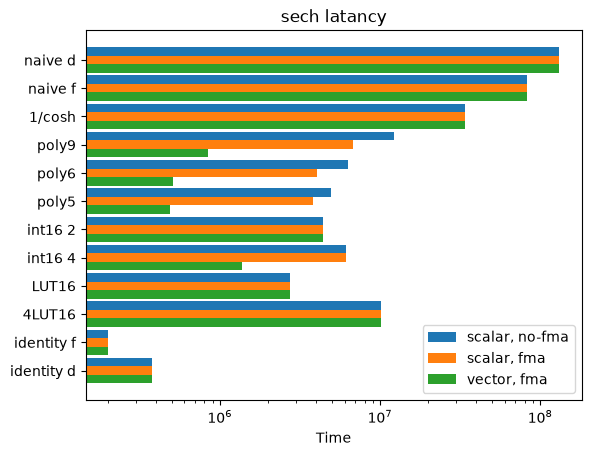

In [114]:

sech = ('naive d','naive f', '1/cosh', 'poly9', 'poly6', 'poly5','int16 2','int16 4','LUT16', '4LUT16' ,'identity f','identity d')
nofma = [ 1.3135010459999998e+08,  8.2233252444444403e+07,  3.3874960571428582e+07,  
         1.2261211175438594e+07,  6.3145322342342352e+06,  4.9083799370629415e+06,  
         4.3914077798742149e+06, 6.1535040614035027e+06,
         2.7213558287937697e+06,  1.0148788086956525e+07,
         2.0100182969557730e+05, 3.7555746030042833e+05]
fma = [ 1.3092979140000001e+08,  8.225e+07,  3.3877363761904769e+07,  
       6.7678487087378614e+06,  4.0623205581395361e+06,  3.8268466413043500e+06,  
       4.3914077798742149e+06, 6.1535040614035027e+06,
       2.7213558287937697e+06,  1.0148788086956525e+07,
       2.0101312205628952e+05, 3.7555746030042833e+05]
vector = [ 1.3102647820000000e+08,  8.2177334000000030e+07,  3.3863212714285724e+07,  
          8.4615814752116054e+05,  5.0772656780275604e+05,  4.8481437656033272e+05,  
          4.3914077798742149e+06, 1.3761720609037334e+06,
          2.7213558287937697e+06,  1.0148788086956525e+07,
          2.0102147271682962e+05, 3.7555746030042833e+05]


print(vector[0]/vector[5])
print((vector[0]-vector[7])/(vector[5]-vector[7]))


# error = [0.2, 0.4, 0.3, 0.6, 0.2]

x = np.arange(len(sech))  # the label locations
width = 0.3  # the width of a bar

fig, ax = plt.subplots()
ax.barh(x-width, nofma, width, align='center', label='scalar, no-fma')
ax.barh(x, fma, width, align='center', label='scalar, fma')
ax.barh(x+width, vector, width, align='center', label='vector, fma')
ax.yaxis.set_inverted(True)  # arrange data from top to bottom
plt.xscale("log")
ax.set_yticks(x,sech)
ax.set_xlabel('Time')
ax.set_title('sech latancy')
ax.legend()

plt.show()

309.7259225772997
501.29679549118737


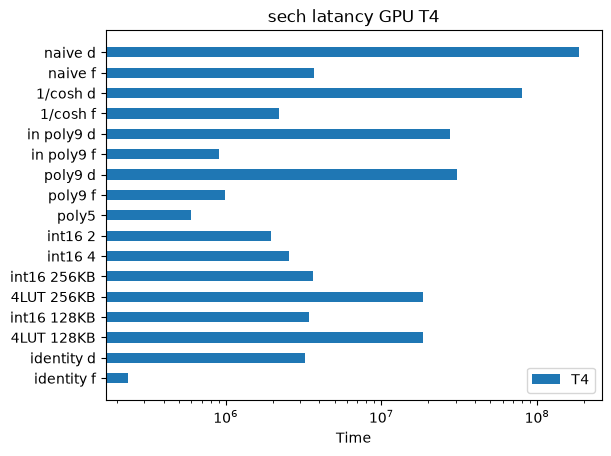

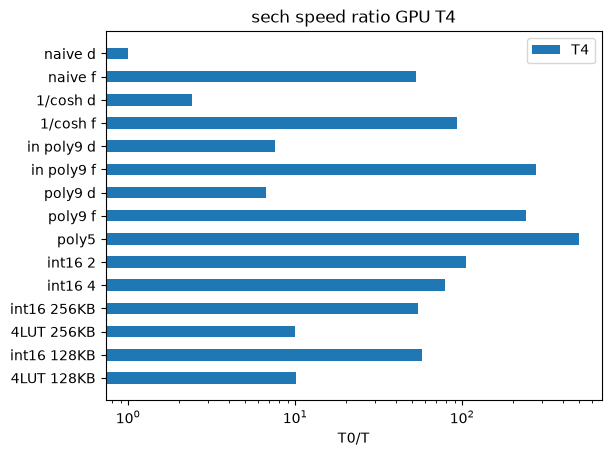

In [115]:

sech = ('naive d','naive f', '1/cosh d', '1/cosh f', 'in poly9 d', 'in poly9 f', 'poly9 d', 'poly9 f', 'poly5','int16 2','int16 4', 'int16 256KB', '4LUT 256KB', 'int16 128KB', '4LUT 128KB', 'identity d','identity f' )
gpuT4 = np.array(
    [186357132,3688056,79595407,2202574,27486569,902677,30519667,993039,601684,1964824,2561600,3625789,18596227,3412825,18418004,3218875,236355])


idd = gpuT4[15]
idf = gpuT4[16]

print(gpuT4[0]/gpuT4[8])
print((gpuT4[0]-idd)/(gpuT4[8]-idf))

x = np.arange(len(sech))  # the label locations
width = 0.5  # the width of a bar

fig, ax = plt.subplots()
ax.barh(x, gpuT4, width, align='center', label='T4')
ax.yaxis.set_inverted(True)  # arrange data from top to bottom
plt.xscale("log")
ax.set_yticks(x,sech)
ax.set_xlabel('Time')
ax.set_title('sech latancy GPU T4')
ax.legend()
plt.show()

id = np.array([idd,idf,idd,idf,idd,idf,idd,idf,idf,idf,idf,idf,idf,idf,idf,idd,idf])

fig, ax = plt.subplots()
ax.barh(x[0:15], (gpuT4[0]-id[0])/(gpuT4-id)[0:15], width, align='center', label='T4')
ax.yaxis.set_inverted(True)  # arrange data from top to bottom
plt.xscale("log")
ax.set_yticks(x[0:15],sech[0:15])
ax.set_xlabel('T0/T')
ax.set_title('sech speed ratio GPU T4')
ax.legend()
plt.show()


70.7725133123427
76.3879359940982


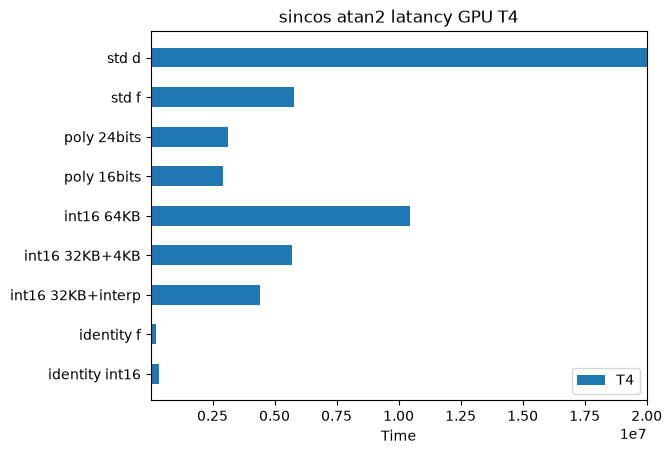

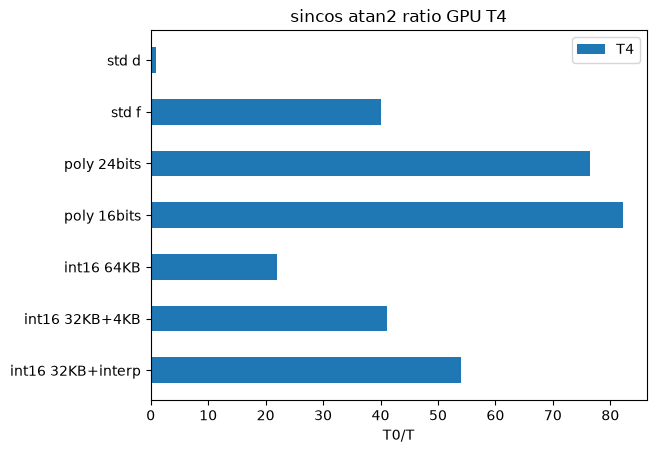

In [116]:
trig = ('std d', 'std f', 'poly 24bits','poly 16bits', 'int16 64KB', 'int16 32KB+4KB', 'int16 32KB+interp', 'identity f', 'identity int16' )
gpuT4 = np.array(
    [222234963,5782052,3140131,2933730,10457102,5717921,4433988,233899,326433]
    )
idf = gpuT4[7]
idi = gpuT4[8]
    
print(gpuT4[0]/gpuT4[2])
print((gpuT4[0]-idf)/(gpuT4[2]-idf))

x = np.arange(len(trig))  # the label locations
width = 0.5  # the width of a bar

fig, ax = plt.subplots()
ax.barh(x, gpuT4, width, align='center', label='T4')
ax.yaxis.set_inverted(True)  # arrange data from top to bottom
#plt.xscale("log")
ax.set_yticks(x,trig)
ax.set_xlabel('Time')
ax.set_title('sincos atan2 latancy GPU T4')
plt.xlim(10**4,2*10**7)
ax.legend()
plt.show()

id = np.array([idf,idf,idf,idf,idi,idi,idi,idf,idi])

fig, ax = plt.subplots()
ax.barh(x[0:7], (gpuT4[0]-id[0])/(gpuT4-id)[0:7], width, align='center', label='T4')
ax.yaxis.set_inverted(True)  # arrange data from top to bottom
#plt.xscale("log")
ax.set_yticks(x[0:7],trig[0:7])
ax.set_xlabel('T0/T')
ax.set_title('sincos atan2 ratio GPU T4')
ax.legend()
plt.show()

77.72727629146853
87.12595368844883


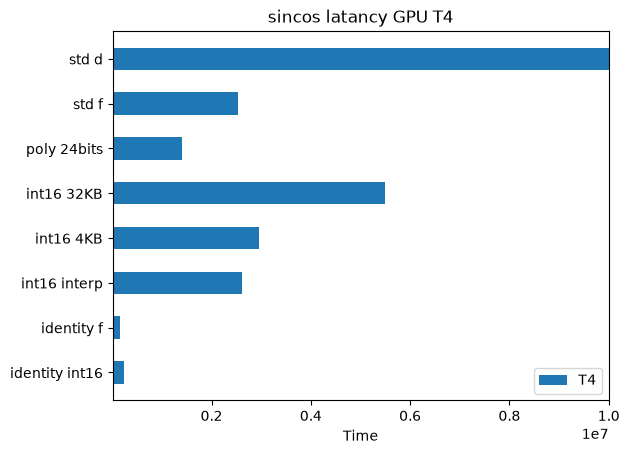

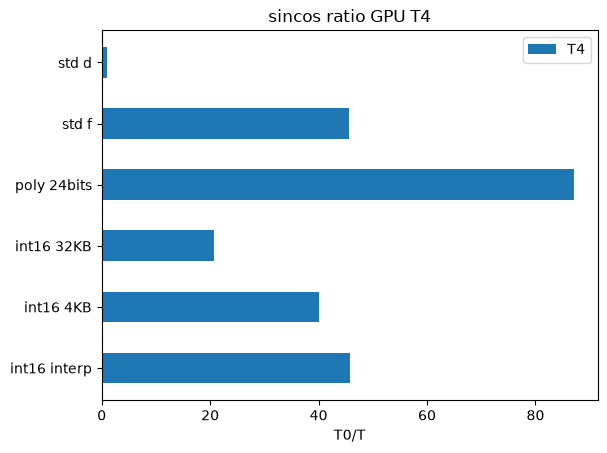

In [118]:
trig = ('std d', 'std f', 'poly 24bits','int16 32KB', 'int16 4KB', 'int16 interp', 'identity f', 'identity int16' )
gpuT4 = np.array(
    [109039010,2537478,1402841,5487628,2946484,2616423,153088,234439]
    )
idf = gpuT4[6]
idi = gpuT4[7]
    
print(gpuT4[0]/gpuT4[2])
print((gpuT4[0]-idf)/(gpuT4[2]-idf))

x = np.arange(len(trig))  # the label locations
width = 0.5  # the width of a bar

fig, ax = plt.subplots()
ax.barh(x, gpuT4, width, align='center', label='T4')
ax.yaxis.set_inverted(True)  # arrange data from top to bottom
#plt.xscale("log")
ax.set_yticks(x,trig)
ax.set_xlabel('Time')
ax.set_title('sincos latancy GPU T4')
plt.xlim(10**4,10**7)
ax.legend()
plt.show()

id = np.array([idf,idf,idf,idi,idi,idi,idf,idi])

fig, ax = plt.subplots()
ax.barh(x[0:6], (gpuT4[0]-id[0])/(gpuT4-id)[0:6], width, align='center', label='T4')
ax.yaxis.set_inverted(True)  # arrange data from top to bottom
#plt.xscale("log")
ax.set_yticks(x[0:6],trig[0:6])
ax.set_xlabel('T0/T')
ax.set_title('sincos ratio GPU T4')
ax.legend()
plt.show()